<center>
    
## Project - House Price Prediction
## Week 9, May 10, 2025
## Arulsree Mozhi, TS

</center>

In [1]:
from IPython.display import display, HTML
import warnings
 
# Suppress warnings
warnings.filterwarnings("ignore")
 
# Apply CSS to wrap long lines in code blocks and adjust font size for tables

display(HTML("""
<style>
    /* Code block styling */
    pre, code {
        background-color: #f4f4f4; /* Light gray background for code */
        border: 1px solid #ddd;
        border-radius: 5px;
        padding: 10px;
        font-family: "Courier New", Courier, monospace;
        font-size: 10px;
        white-space: pre-wrap; /* Wrap long lines in code blocks */
        max-width: 100%;
        overflow-x: auto; /* Allow horizontal scrolling for large code blocks */
    }
    /* Table styling */
    table {
        font-family: Arial, sans-serif;
        font-size: 10px; /* Set the font size for tables */
        border-collapse: collapse;
        width: 100%;
    }
    table, th, td {
        border: 1px solid #ddd; /* Light border for table, header, and cells */
    }
    th {
        background-color: #f2f2f2; /* Light gray background for table header */
         word-wrap: break-word
    }
    th, td {
        padding: 8px;
        text-align: center !important; /* Align table content to center */
        width: 100px;
    }
</style>
"""))


Data Loaded Successfully!
Dataset shape: (2930, 82)

Starting Data Cleaning...
Data Cleaning & Feature Engineering Completed.

Generating Visualizations...


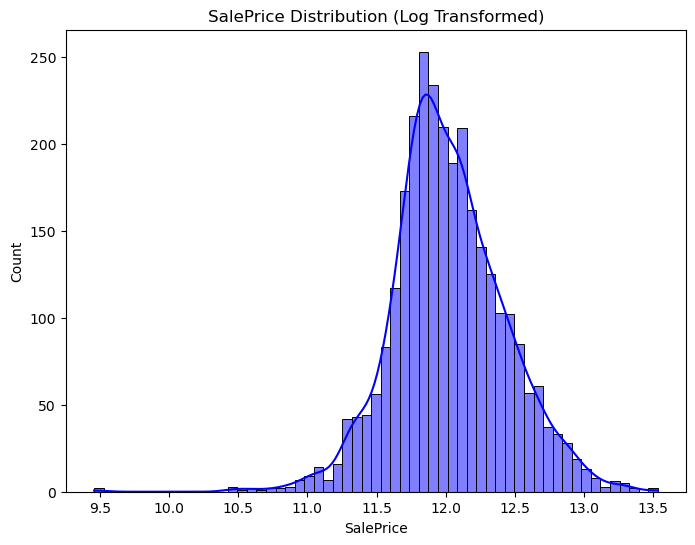

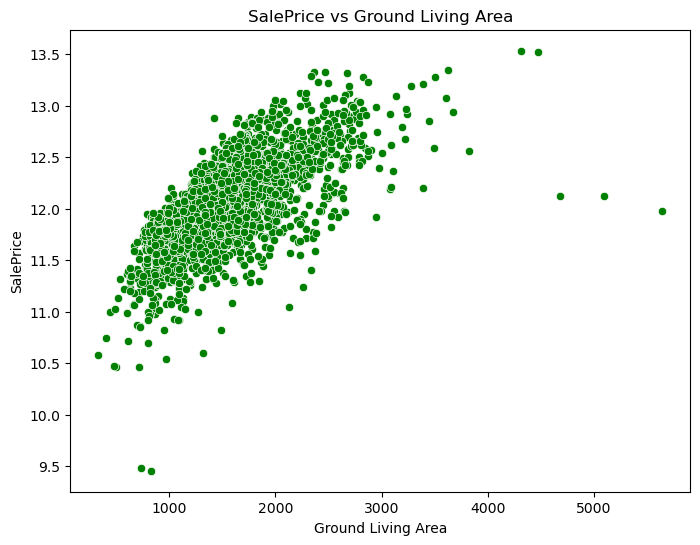

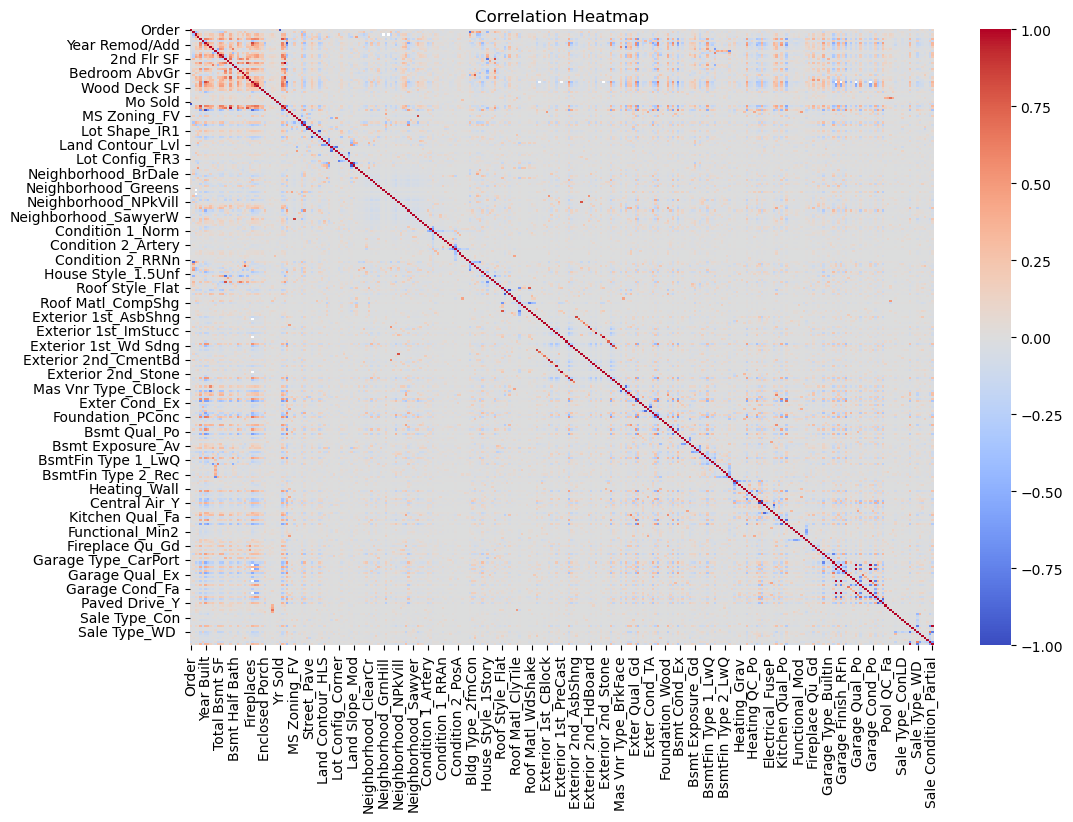


Model Evaluation Metrics:
╒═══════════════════════════╤══════════════════╕
│ Metric                    │ Value            │
╞═══════════════════════════╪══════════════════╡
│ Mean Squared Error (MSE)  │ 1,436,316,419.94 │
├───────────────────────────┼──────────────────┤
│ Mean Absolute Error (MAE) │ 16,462.33        │
├───────────────────────────┼──────────────────┤
│ R-Squared (R²)            │ 0.8209           │
╘═══════════════════════════╧══════════════════╛


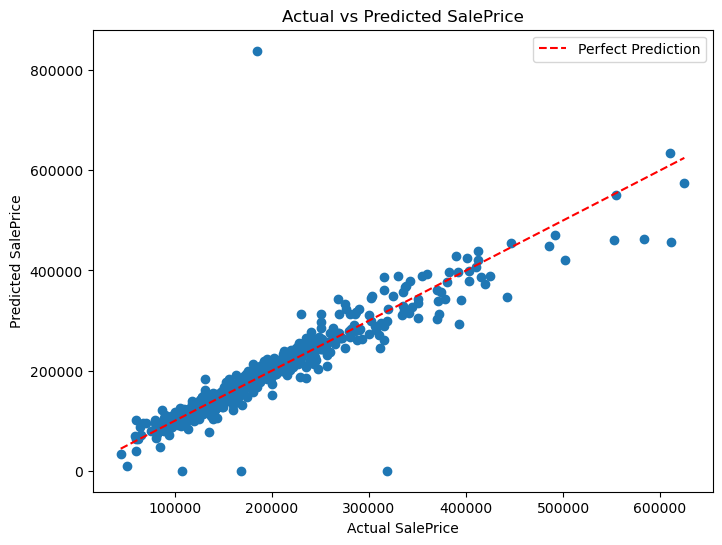

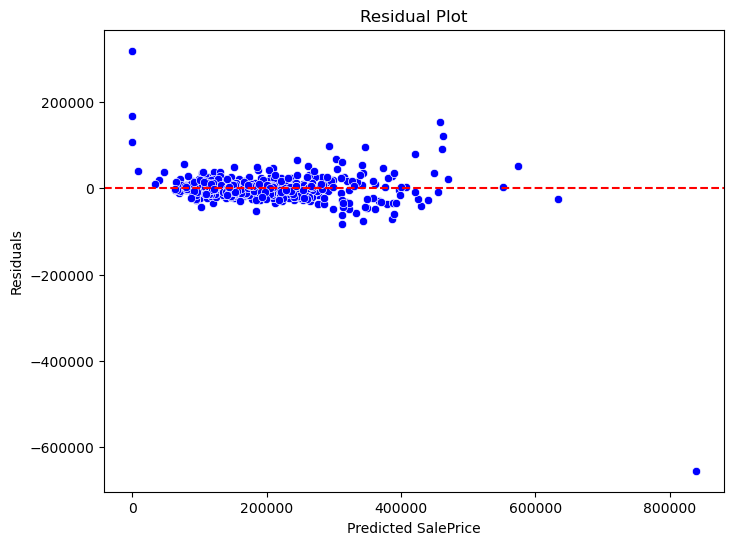

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. Load the dataset
df = pd.read_csv('../Data/dataset_sample.csv')

print("\n\033[1mData Loaded Successfully!\033[0m")
print(f"Dataset shape: {df.shape}")

# 2. Data Cleaning and Preprocessing
print("\n\033[1mStarting Data Cleaning...\033[0m")

# Handle missing values: For 'Lot Frontage', we impute with median per neighborhood
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

# Filling categorical variables with 'None' where data is missing
df.fillna({
    'Garage Type': 'None',
    'Garage Finish': 'None',
    'Garage Qual': 'None',
    'Garage Cond': 'None',
    'Mas Vnr Type': 'None'
}, inplace=True)

# Fill numerical missing values for 'Mas Vnr Area' with 0
df['Mas Vnr Area'].fillna(0, inplace=True)

# Drop irrelevant columns that won't help in prediction
drop_cols = ['PID', 'Alley', 'PoolQC', 'Fence', 'Misc Feature']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Feature Engineering: Creating new features
df['TotalSF'] = df['Gr Liv Area'] + df['1st Flr SF'] + df['2nd Flr SF']  # Total square footage of the house
df['HouseAge'] = df['Yr Sold'] - df['Year Built']  # Age of the house at the time of sale

# Log-transform SalePrice to reduce skewness
df['SalePrice'] = np.log1p(df['SalePrice'])

# One-hot encoding for categorical features
df = pd.get_dummies(df)

print("\033[1mData Cleaning & Feature Engineering Completed.\033[0m")

# 3. Exploratory Data Analysis (EDA)
print("\n\033[1mGenerating Visualizations...\033[0m")

# Distribution of SalePrice (Log Transformed)
plt.figure(figsize=(8, 6))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('SalePrice Distribution (Log Transformed)')
plt.xlabel('SalePrice')
plt.show()

# Scatterplot for SalePrice vs Ground Living Area
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Gr Liv Area'], y=df['SalePrice'], color='green')
plt.title('SalePrice vs Ground Living Area')
plt.xlabel('Ground Living Area')
plt.ylabel('SalePrice')
plt.show()

# Correlation heatmap to explore relationships between features
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 4. Prepare Data for Modeling
X = df.drop('SalePrice', axis=1)  # Features
y = df['SalePrice']  # Target variable

# Impute missing values in features (though the data has been cleaned already)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features to standardize them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Building: Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 6. Predictions: Predict SalePrice on test set
y_pred = model.predict(X_test_scaled)

# Apply inverse transformation to predictions and actual values
y_pred_exp = np.expm1(y_pred)  # Reverse the log transformation
y_test_exp = np.expm1(y_test)

# 7. Evaluation: Calculate and display metrics
mse = mean_squared_error(y_test_exp, y_pred_exp)
mae = mean_absolute_error(y_test_exp, y_pred_exp)
r2 = r2_score(y_test_exp, y_pred_exp)

metrics_table = [
    ["Mean Squared Error (MSE)", f"{mse:,.2f}"],
    ["Mean Absolute Error (MAE)", f"{mae:,.2f}"],
    ["R-Squared (R²)", f"{r2:,.4f}"]
]

print("\n\033[1mModel Evaluation Metrics:\033[0m")
print(tabulate(metrics_table, headers=["Metric", "Value"], tablefmt="fancy_grid"))

# 8. Visualization of Predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test_exp, y_pred_exp)
plt.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], '--r', label='Perfect Prediction')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.savefig('ScatterPlot.png')  # You can change the file name and extension
plt.legend()
plt.show()

# 9. Residual Plot: Check for homoscedasticity
residuals = y_test_exp - y_pred_exp
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_exp, y=residuals, color='blue')
plt.axhline(0, color='red', linestyle='--')  # Line at zero for reference
plt.title('Residual Plot')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.savefig('ResidualPlot.png')  # You can change the file name and extension
plt.show()


In [3]:
import sklearn
import pandas as pd
import numpy as np

print(sklearn.__version__)
print(pd.__version__)
print(np.__version__)


1.2.2
2.1.4
1.26.4


## Overall Summary

### 1. Data Preparation
#### Data Cleaning
We began by loading the Ames Housing dataset and performing the following steps to clean the data:

- **Missing Data Handling:** 
  - For the `Lot Frontage` column, missing values were filled with the median value of the corresponding `Neighborhood`.
  - Other categorical columns such as `Garage Type`, `Garage Finish`, `Garage Qual`, `Garage Cond`, and `Mas Vnr Type` were filled with 'None'.
  - The `Mas Vnr Area` column was filled with 0 for missing values.
  
- **Removing Irrelevant Columns:**
  We dropped the following columns which were deemed irrelevant for our analysis:
  - `PID`, `Alley`, `PoolQC`, `Fence`, and `Misc Feature`.

#### Feature Engineering
- **Total Square Footage:** 
  A new feature, `TotalSF`, was created by summing the following columns:
  - `Gr Liv Area`, `1st Flr SF`, and `2nd Flr SF`.
  
- **House Age:** 
  We created the `HouseAge` feature by calculating the difference between the `Yr Sold` and `Year Built` columns.
  
- **Log Transformation of Sale Price:**
  The target variable, `SalePrice`, was log-transformed to normalize the distribution and reduce skewness.

#### One-Hot Encoding
We performed one-hot encoding for all categorical variables to convert them into numerical representations suitable for modeling.

### 2. Model Building and Evaluation
#### Model Selection
We chose **Linear Regression** as our initial model due to its simplicity and interpretability. Linear regression is a suitable choice for this type of problem, where we aim to predict a continuous variable (house price) based on a set of input features.

#### Model Evaluation
We used the following evaluation metrics to assess the performance of our model:

- **Mean Squared Error (MSE):** 1,436,316,419.94
- **Mean Absolute Error (MAE):** 16,462.33
- **R-Squared (R²):** 0.8209

#### Interpretation of Results
- **R-Squared (0.8209):** This indicates that the model explains about **82.09%** of the variance in house prices, suggesting that the model has strong predictive power.
- **MSE and MAE:** These values are reasonable, indicating that the model’s predictions are relatively close to the actual values on average.

The **residual plot** suggests that there are still patterns in the data that the linear model cannot fully capture. This implies that more complex models or additional feature engineering might help improve model performance.

### 3. Conclusion and Recommendations
#### Conclusion
The Linear Regression model provides a reasonable prediction of house prices with an **R² of 0.8209**, which indicates strong predictive power. However, the residual plot suggests that the model could be improved by capturing more complex patterns in the data.

#### Recommendations
1. **Try more complex models** like **Random Forest** or **XGBoost** for better performance, as these models can capture more complex relationships.
2. **Add more feature engineering**, including **interaction terms** or exploring **external variables** that may better explain variations in house prices.
3. **Use cross-validation** and **regularization techniques** (e.g., Ridge or Lasso regression) to prevent overfitting and improve the generalization of the model.